In [33]:
!pip install numpy
import kagglehub

# Download latest version
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


100%|██████████| 149M/149M [00:04<00:00, 38.6MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1


In [36]:
train_dir = '/root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1/Training'
test_dir  = '/root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1/Testing'

In [34]:
!pip install segmentation-models

  Obtaining dependency information for segmentation-models from https://files.pythonhosted.org/packages/da/b9/4a183518c21689a56b834eaaa45cad242d9ec09a4360b5b10139f23c63f4/segmentation_models-1.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for keras-applications<=1.0.8,>=1.0.7 from https://files.pythonhosted.org/packages/71/e3/19762fdfc62877ae9102edf6342d71b28fbfd9dea3d2f96a882ce099b03f/Keras_Applications-1.0.8-py3-none-any.whl.metadata
  Obtaining dependency information for image-classifiers==1.0.0 from https://files.pythonhosted.org/packages/81/98/6f84720e299a4942ab80df5f76ab97b7828b24d1de5e9b2cbbe6073228b7/image_classifiers-1.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for efficientnet==1.0.0 from https://files.pythonhosted.org/packages/97/82/f3ae07316f0461417dc54affab6e86ab188a5a22f33176d35271628b96e0/efficientnet-1.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for scikit-image from https://files.pythonhosted.org/packages/a5

In [ ]:
from PIL import Image
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dropout, MaxPooling2D, Flatten, Dense

In [37]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Medical Standard Augmentation Performed

train_datagen = ImageDataGenerator(               
    rescale=1./255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=(0.95, 1.05),
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

#Splitting The Train and Test Data

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [38]:
import os

#Setting The Environment as per Required

os.environ["SM_FRAMEWORK"] = "tf.keras"

import segmentation_models as sm

#For Unet Backbone Will be Used The Famous Resnet-34. Mostly Used in Medical Imaging

BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

Segmentation Models: using `tf.keras` framework.


In [39]:
import tensorflow as tf

def softmax_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # get number of dims
    axes = list(range(len(y_true.shape)-1))  

    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true + y_pred, axis=axes)

    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - tf.reduce_mean(dice)

In [49]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,BatchNormalization,Dropout
import segmentation_models as sm

conv_base = sm.Unet(
    backbone_name='resnet34', 
    input_shape=(256,256, 3)
)

'''
from tensorflow.keras.applications import EfficientNetB0
conv_base = EfficientNetB0(include_top=False, input_shape=(256, 256, 3))
'''

#conv_base.trainable = False

#

model = Sequential([
    conv_base,

    Flatten(), 
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(4, activation='softmax')
])

#Two optimizers will be tested. Adadelta and AdamW. Adadelta is kinda self-regulating, for stabilization it will be prefered

from tensorflow.keras.optimizers import Adadelta, AdamW

optimizer = Adadelta(learning_rate=0.01)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_7 (Functional)        (None, 256, 256, 1)       24456154  
                                                                 
 flatten_4 (Flatten)         (None, 65536)             0         
                                                                 
 dense_18 (Dense)            (None, 256)               16777472  
                                                                 
 batch_normalization_12 (Ba  (None, 256)               1024      
 tchNormalization)                                               
                                                                 
 dropout_12 (Dropout)        (None, 256)               0         
                                                                 
 dense_19 (Dense)            (None, 128)               32896     
                                                      

In [50]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=1000,               #Forcefully done so that all the epochs can run ok
    restore_best_weights=True,
    verbose=1
)

In [51]:
history = model.fit(train_gen,epochs=100,validation_data=test_gen, verbose=1, callbacks=[early_stop], batch_size=16)

Epoch 1/100


2026-01-14 18:22:11.149151: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-01-14 18:22:11.244917: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-01-14 18:22:11.244942: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-01-14 18:22:11.245347: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-01-14 18:22:11.245422: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-01-14

179/179 [==============================] - 163s 297ms/step - loss: 1.5409 - accuracy: 0.3554 - val_loss: 1.4176 - val_accuracy: 0.2982
Epoch 2/100
179/179 [==============================] - 46s 257ms/step - loss: 1.1586 - accuracy: 0.5166 - val_loss: 2.1970 - val_accuracy: 0.3089
Epoch 3/100
179/179 [==============================] - 46s 257ms/step - loss: 0.9487 - accuracy: 0.6369 - val_loss: 1.9286 - val_accuracy: 0.3112
Epoch 4/100
179/179 [==============================] - 46s 257ms/step - loss: 0.8486 - accuracy: 0.6915 - val_loss: 1.5406 - val_accuracy: 0.3211
Epoch 5/100
179/179 [==============================] - 46s 258ms/step - loss: 0.7466 - accuracy: 0.7446 - val_loss: 0.9073 - val_accuracy: 0.6568
Epoch 6/100
179/179 [==============================] - 46s 259ms/step - loss: 0.6745 - accuracy: 0.7782 - val_loss: 0.8050 - val_accuracy: 0.7094
Epoch 7/100
179/179 [==============================] - 46s 256ms/step - loss: 0.6141 - accuracy: 0.8062 - val_loss: 0.6442 - val_accura

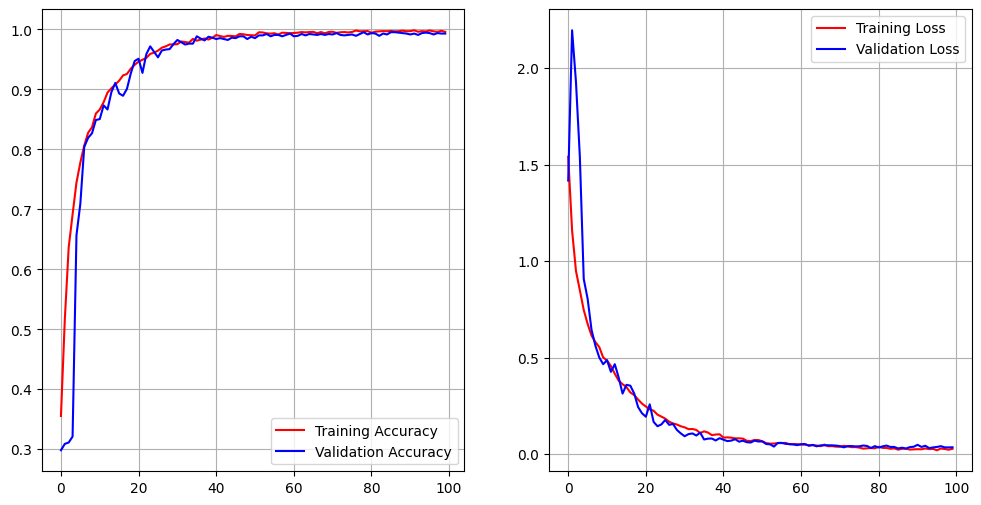

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],'r',label="Training Accuracy")
plt.plot(history.history['val_accuracy'],'b',label="Validation Accuracy")
plt.legend()
plt.grid(True) 

plt.subplot(1,2,2)
plt.plot(history.history['loss'],'r',label="Training Loss")
plt.plot(history.history['val_loss'],'b',label="Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
# Confusion Matrix

Found 1311 images belonging to 4 classes.
41/41 [==============================] - 2s 30ms/step


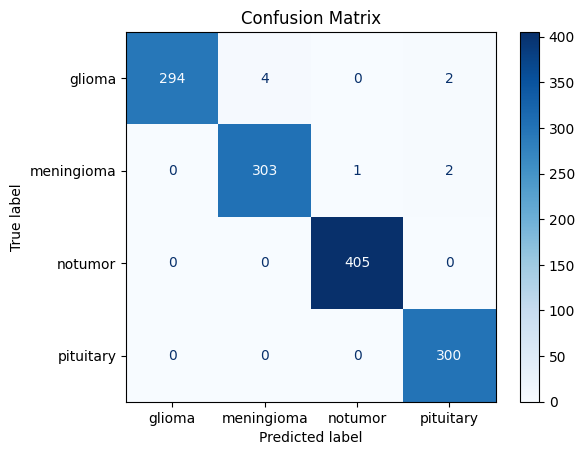

In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [56]:
model.save("Unet-BrainTumor.h5")

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
/root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1/Testing/glioma/Te-glTr_0000.jpg

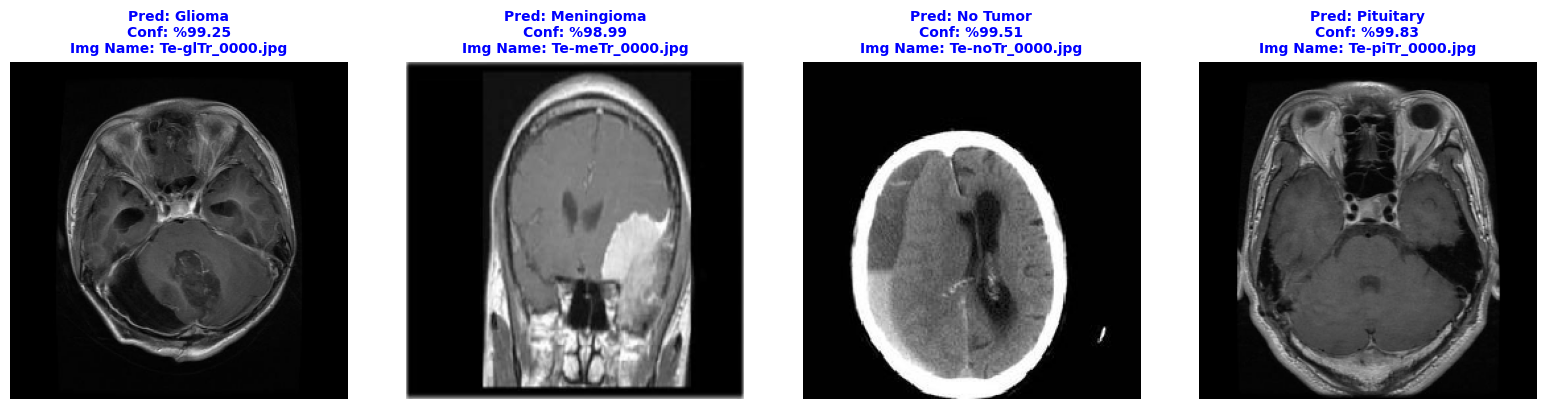

Toplam 4 fotoğraf için tahmin tamamlandı.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf
# --- 1. AYARLAR ---
folder_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Brain Tumor\TEST"
model = tf.keras.models.load_model(r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Brain Tumor\Unet-BrainTumor.h5")
target_size = (256, 256)
class_indices = {0: 'Glioma', 1: 'Meningioma', 2: 'No Tumor', 3: 'Pituitary'}

# Klasördeki dosyaları listele ve ilk 4 geçerli resmi al
all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
selected_images = all_images[:4] # İlk 4 fotoğrafı seçer

# --- 2. GÖRSELLEŞTİRME AYARI ---
plt.figure(figsize=(16, 4)) # Geniş bir figür oluştur (4 fotoğraf yan yana)

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(folder_path, img_name)
    
    # Görüntü hazırlama
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array_rescaled = img_array / 255.0
    img_array_batch = np.expand_dims(img_array_rescaled, axis=0)

    # Tahmin
    y_pred_prob = model.predict(img_array_batch, verbose=0)
    y_pred_class = np.argmax(y_pred_prob, axis=1)[0]
    predicted_class_name = class_indices.get(y_pred_class, f"Sınıf {y_pred_class}")
    confidence = np.max(y_pred_prob) * 100

    # 4 alt grafikten (subplot) ilgili olanı seç
    plt.subplot(1, 4, i + 1)
    plt.imshow(img_array.astype('uint8'))
    plt.axis('off')
    
    # Başlıklandırma
    plt.title(f"Pred: {predicted_class_name}\nConf: %{confidence:.2f}\nImg Name: {img_name}", 
              fontsize=10, color='blue', fontweight='bold')

plt.tight_layout() # Grafikler arası boşluğu düzenle
plt.show()

# Konsola toplu rapor
print(f"Toplam {len(selected_images)} fotoğraf için tahmin tamamlandı.")